In [ ]:
# 1. Seleccionar variables clave de su dataset
# 2. Crear al menos 3 visualizaciones
# 3. Identificar patrones, tendencias o correlaciones
# 4. Interpretar resultados en contexto de su problema
# 5. Documentar con Copilot hallazgos y decisiones

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
clientes = pd.read_excel('./data/raw/clientes.xlsx')
ventas = pd.read_excel('./data/raw/ventas.xlsx')
productos = pd.read_excel('./data/raw/productos.xlsx')
detalle_ventas = pd.read_excel('./data/raw/detalle_ventas.xlsx')

In [4]:
print("Clientes:", clientes.shape)
print("Productos:", productos.shape)
print("Ventas:", ventas.shape)
print("Detalle Ventas:", detalle_ventas.shape)

Clientes: (100, 5)
Productos: (100, 4)
Ventas: (120, 6)
Detalle Ventas: (343, 6)


In [5]:
for name, df in {'clientes': clientes, 'productos': productos, 'ventas': ventas, 'detalle_ventas': detalle_ventas}.items():
    print(f"===== {name.upper()} =====")
    display(df.head())
    print(df.info(), "\n")

===== CLIENTES =====


,id_cliente,nombre_cliente,email,ciudad,fecha_alta
0,1,Mariana Lopez,mariana.lopez@mail.com,Carlos Paz,2023-01-01
1,2,Nicolas Rojas,nicolas.rojas@mail.com,Carlos Paz,2023-01-02
2,3,Hernan Martinez,hernan.martinez@mail.com,Rio Cuarto,2023-01-03
3,4,Uma Martinez,uma.martinez@mail.com,Carlos Paz,2023-01-04
4,5,Agustina Flores,agustina.flores@mail.com,Cordoba,2023-01-05


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_cliente      100 non-null    int64         
 1   nombre_cliente  100 non-null    object        
 2   email           100 non-null    object        
 3   ciudad          100 non-null    object        
 4   fecha_alta      100 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 4.0+ KB
None 

===== PRODUCTOS =====


,id_producto,nombre_producto,categoria,precio_unitario
0,1,Coca Cola 1.5L,Alimentos,2347
1,2,Pepsi 1.5L,Limpieza,4973
2,3,Sprite 1.5L,Alimentos,4964
3,4,Fanta Naranja 1.5L,Limpieza,2033
4,5,Agua Mineral 500ml,Alimentos,4777


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id_producto      100 non-null    int64 
 1   nombre_producto  100 non-null    object
 2   categoria        100 non-null    object
 3   precio_unitario  100 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 3.3+ KB
None 

===== VENTAS =====


,id_venta,fecha,id_cliente,nombre_cliente,email,medio_pago
0,1,2024-06-19,62,Guadalupe Romero,guadalupe.romero@mail.com,tarjeta
1,2,2024-03-17,49,Olivia Gomez,olivia.gomez@mail.com,qr
2,3,2024-01-13,20,Tomas Acosta,tomas.acosta@mail.com,tarjeta
3,4,2024-02-27,36,Martina Molina,martina.molina@mail.com,transferencia
4,5,2024-06-11,56,Bruno Diaz,bruno.diaz@mail.com,tarjeta


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_venta        120 non-null    int64         
 1   fecha           120 non-null    datetime64[ns]
 2   id_cliente      120 non-null    int64         
 3   nombre_cliente  120 non-null    object        
 4   email           120 non-null    object        
 5   medio_pago      120 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 5.8+ KB
None 

===== DETALLE_VENTAS =====


,id_venta,id_producto,nombre_producto,cantidad,precio_unitario,importe
0,1,90,Toallas Húmedas x50,1,2902,2902
1,2,82,Aceitunas Negras 200g,5,2394,11970
2,2,39,Helado Vainilla 1L,5,469,2345
3,2,70,Fernet 750ml,2,4061,8122
4,2,22,Medialunas de Manteca,1,2069,2069


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 343 entries, 0 to 342
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id_venta         343 non-null    int64 
 1   id_producto      343 non-null    int64 
 2   nombre_producto  343 non-null    object
 3   cantidad         343 non-null    int64 
 4   precio_unitario  343 non-null    int64 
 5   importe          343 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 16.2+ KB
None 



In [13]:
# probar visualizar
df = detalle_ventas.copy()

In [14]:
display(df.head())

,id_venta,id_producto,nombre_producto,cantidad,precio_unitario,importe
0,1,90,Toallas Húmedas x50,1,2902,2902
1,2,82,Aceitunas Negras 200g,5,2394,11970
2,2,39,Helado Vainilla 1L,5,469,2345
3,2,70,Fernet 750ml,2,4061,8122
4,2,22,Medialunas de Manteca,1,2069,2069


In [16]:
num_cols = ['precio_unitario', 'cantidad','importe']
display(df[num_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
precio_unitario,343.0,2654.495627,1308.694720,272.0,1618.5,2512.0,3876.0,4982.0
cantidad,343.0,2.962099,1.366375,1.0,2.0,3.0,4.0,5.0
importe,343.0,7730.078717,5265.543077,272.0,3489.0,6702.0,10231.5,24865.0


In [17]:
df_raw= df.copy()
df_raw.to_csv('./data/interim/bd_test_detalle_ventas.csv', index=False)

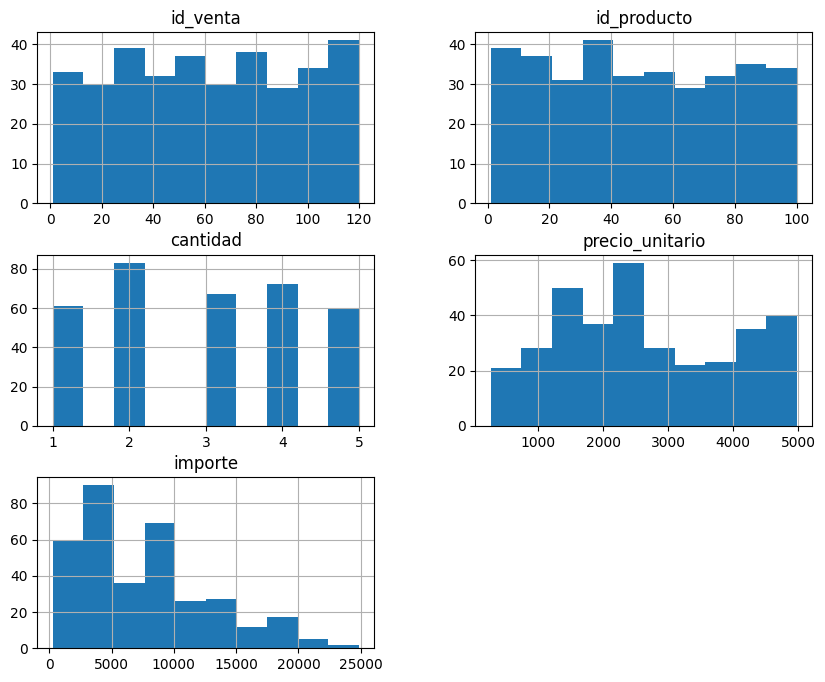

In [18]:
df.hist(figsize=(10,8))
plt.show()

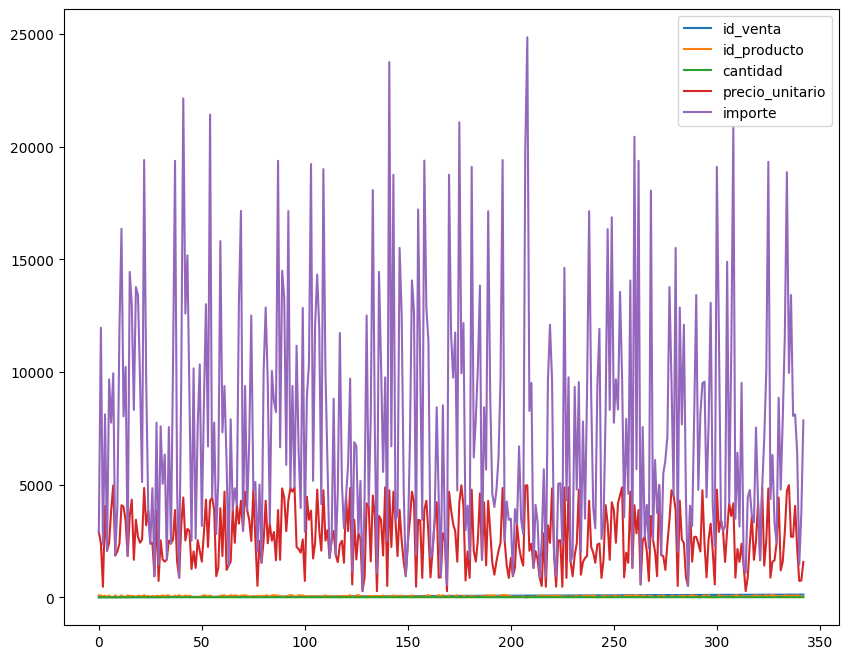

In [19]:
df.plot(figsize=(10,8))
plt.show()

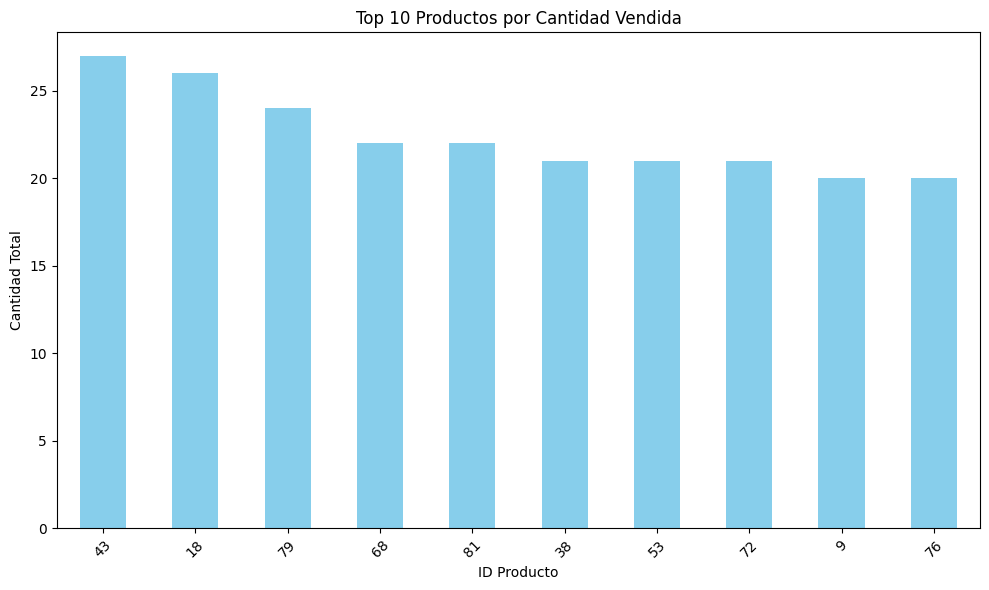

In [22]:
# Ejemplo 1: Top 10 productos por cantidad total vendida
top_productos = df.groupby('id_producto')['cantidad'].sum().nlargest(10)
top_productos.plot.bar(figsize=(10,6), color='skyblue')
plt.title('Top 10 Productos por Cantidad Vendida')
plt.xlabel('ID Producto')
plt.ylabel('Cantidad Total')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

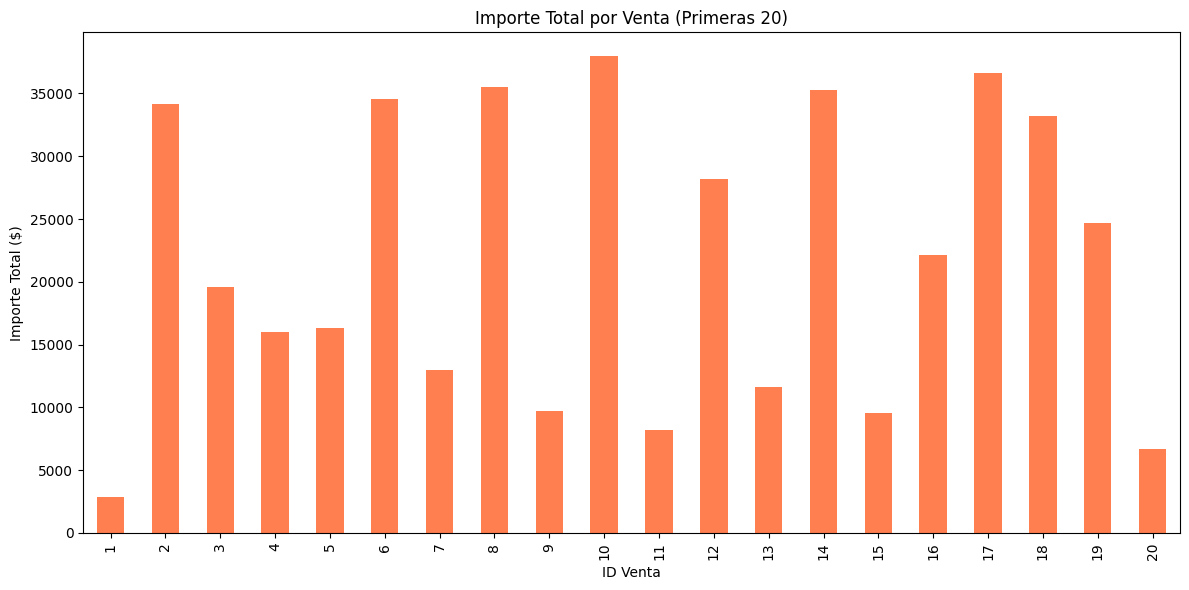

In [23]:
# Ejemplo 2: Importe total por venta (primeras 20 ventas)
df.groupby('id_venta')['importe'].sum().head(20).plot.bar(figsize=(12,6), color='coral')
plt.title('Importe Total por Venta (Primeras 20)')
plt.xlabel('ID Venta')
plt.ylabel('Importe Total ($)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

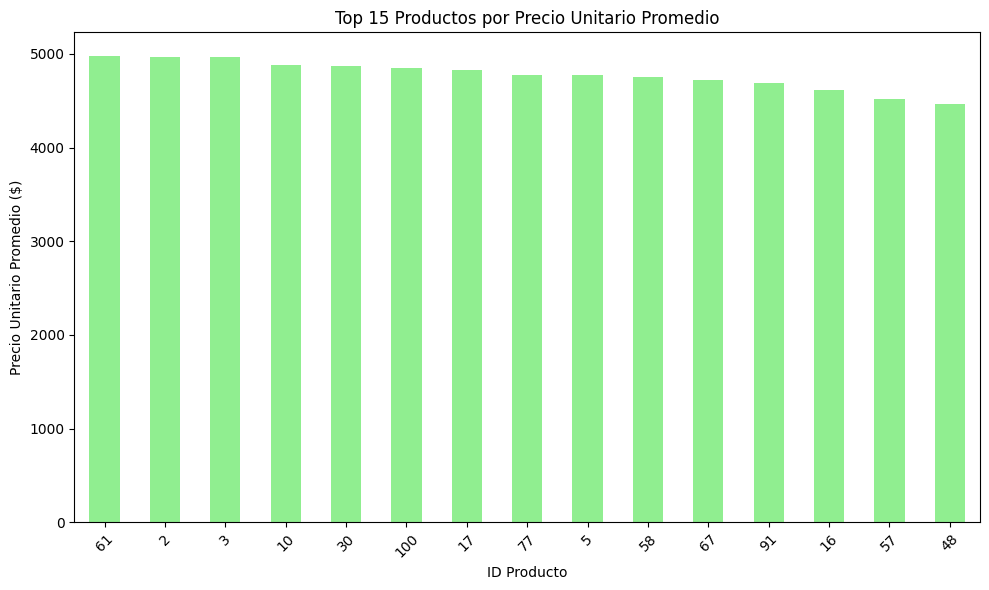

In [24]:
# Ejemplo 3: Comparación precio unitario promedio por producto (top 15)
precio_promedio = df.groupby('id_producto')['precio_unitario'].mean().nlargest(15)
precio_promedio.plot.bar(figsize=(10,6), color='lightgreen')
plt.title('Top 15 Productos por Precio Unitario Promedio')
plt.xlabel('ID Producto')
plt.ylabel('Precio Unitario Promedio ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()